# Task 10 — Pipeline Engineering with Scikit-Learn

## Objective

The objective of this task is to build a reproducible and modular machine learning pipeline using Scikit-Learn. The pipeline integrates data preprocessing, feature transformation, model training, prediction, and serialization into a single workflow.

The task addresses a business problem where inconsistent preprocessing across multiple notebooks can cause differences between training and production data processing. A unified pipeline helps ensure that the same transformations are applied consistently during both training and inference.

## Dataset

The Titanic dataset is used for this task. It contains passenger information such as passenger class, age, sex, fare, family information, and other attributes.

### Target Variable

`Survived`

- `0` — Did not survive
- `1` — Survived

## Key Techniques

- Scikit-Learn Pipeline
- ColumnTransformer
- Custom Transformer
- Feature Union
- Data preprocessing
- Leakage prevention
- Model evaluation
- Joblib pipeline serialization

## Workflow

1. Dataset exploration
2. Data cleaning
3. Train-test split
4. Preprocessing with ColumnTransformer
5. Custom feature transformation
6. Pipeline construction
7. Baseline comparison
8. Model evaluation
9. Pipeline serialization with Joblib
10. Verification of the saved pipeline

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 1. Dataset Loading

The Titanic training dataset is loaded for analysis. The `Survived` column is used as the target variable, while the remaining relevant passenger attributes are considered as input features.

In [2]:
df = pd.read_csv("Titanic-Train.csv.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    i

## 2. Exploratory Data Analysis

Initial exploratory analysis is performed to understand the structure of the dataset, identify missing values, inspect duplicate records, and examine the distribution of the target variable.

This step is important because preprocessing decisions should be based on the actual characteristics of the dataset.

In [4]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing.sort_values("Missing Values", ascending=False))

,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate rows: 0
Duplicate percentage: 0.0 %


In [6]:
print("Survival Distribution:")
print(df["Survived"].value_counts())

print("\nSurvival Percentage:")
print((df["Survived"].value_counts(normalize=True) * 100).round(2))

Survival Distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


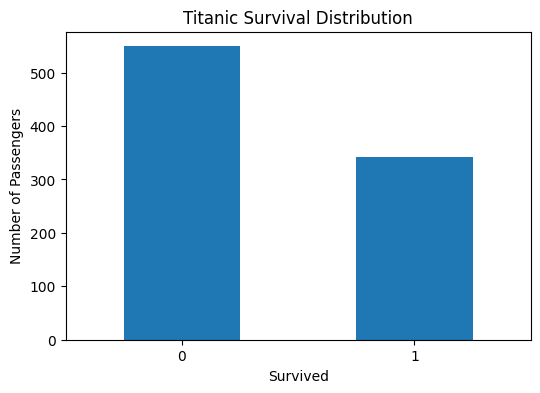

In [7]:
df["Survived"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()

In [8]:
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
display(df.describe(include="object"))

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


## 3. Data Cleaning and Feature Selection

The dataset contains passenger attributes with different data types and missing-value patterns. Instead of applying the same preprocessing operation to every column, numerical and categorical features are handled separately.

Identifiers and high-cardinality textual fields that are not directly required for the baseline pipeline are excluded where appropriate.

The preprocessing operations will be placed inside the Scikit-Learn pipeline so that they are fitted only on the training data and consistently applied to unseen data.

In [10]:
target = "Survived"

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X shape: (891, 7)
y shape: (891,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (712, 7)
Testing set shape: (179, 7)

Training target distribution:
Survived
0    439
1    273
Name: count, dtype: int64

Testing target distribution:
Survived
0    110
1     69
Name: count, dtype: int64


## 4. Preprocessing Design

A `ColumnTransformer` is used to apply different preprocessing strategies to numerical and categorical features.

### Numerical Features

Missing numerical values are replaced using the median and then standardized using `StandardScaler`.

### Categorical Features

Missing categorical values are replaced using the most frequent category and then converted into numerical form using one-hot encoding.

Keeping these operations inside the pipeline prevents preprocessing from being fitted separately outside the model workflow and reduces the risk of data leakage.

In [12]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical features: ['Sex', 'Embarked']


In [13]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [14]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


## 5. Custom Transformer

A custom transformer is implemented using Scikit-Learn's `BaseEstimator` and `TransformerMixin` interfaces.

The transformer creates a family-size feature from `SibSp` and `Parch`. This demonstrates how custom feature engineering can be integrated directly into a Scikit-Learn pipeline.

In [16]:
class FamilySizeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1

        return X

In [17]:
custom_transformer = FamilySizeTransformer()

X_train_custom = custom_transformer.fit_transform(X_train)
X_test_custom = custom_transformer.transform(X_test)

print("Original training shape:", X_train.shape)
print("After custom transformation:", X_train_custom.shape)

display(X_train_custom.head())

Original training shape: (712, 7)
After custom transformation: (712, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
692,3,male,NaN,0,0,56.4958,S,1
481,2,male,NaN,0,0,0.0000,S,1
527,1,male,NaN,0,0,221.7792,S,1
855,3,female,18.0,0,1,9.3500,S,2
801,2,female,31.0,1,1,26.2500,S,3


In [18]:
numeric_features_updated = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_updated = [
    "Sex",
    "Embarked"
]

In [19]:
numeric_pipeline_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_final = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_final, numeric_features_updated),
        ("cat", categorical_pipeline_final, categorical_features_updated)
    ]
)

print("Final ColumnTransformer created.")

Final ColumnTransformer created.


## 6. Complete Machine Learning Pipeline

The complete pipeline combines the custom feature transformation, ColumnTransformer preprocessing, and Random Forest classifier.

This ensures that feature engineering and preprocessing are executed consistently before prediction.

In [20]:
pipeline = Pipeline(steps=[
    ("feature_engineering", FamilySizeTransformer()),
    ("preprocessing", preprocessor_final),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

print("Complete pipeline created successfully.")

Complete pipeline created successfully.


In [21]:
pipeline.fit(X_train, y_train)

print("Pipeline training completed successfully.")

Pipeline training completed successfully.


In [22]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 179


In [23]:
pipeline_accuracy = accuracy_score(y_test, y_pred)
pipeline_precision = precision_score(y_test, y_pred, zero_division=0)
pipeline_recall = recall_score(y_test, y_pred, zero_division=0)
pipeline_f1 = f1_score(y_test, y_pred, zero_division=0)

print("Pipeline Model Results")
print("----------------------------------------")
print(f"Accuracy: {pipeline_accuracy:.4f}")
print(f"Precision: {pipeline_precision:.4f}")
print(f"Recall: {pipeline_recall:.4f}")
print(f"F1 Score: {pipeline_f1:.4f}")

Pipeline Model Results
----------------------------------------
Accuracy: 0.8045
Precision: 0.7742
Recall: 0.6957
F1 Score: 0.7328


In [24]:
print("Classification Report")
print("----------------------------------------")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did Not Survive", "Survived"],
    zero_division=0
))

Classification Report
----------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



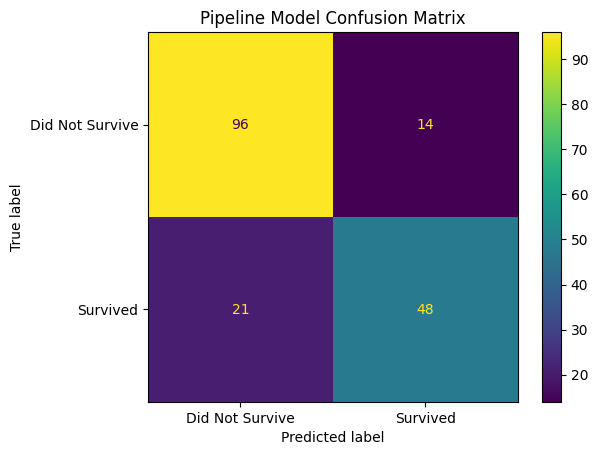

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Pipeline Model Confusion Matrix")
plt.show()

## 7. Baseline Model

A simple baseline Random Forest model is trained separately for comparison.

The baseline provides a reference point for evaluating whether the engineered pipeline provides useful performance while also improving reproducibility and preprocessing consistency.

In [26]:
baseline_model = Pipeline(steps=[
    ("preprocessing", preprocessor_final),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

X_train_baseline = FamilySizeTransformer().fit_transform(X_train)
X_test_baseline = FamilySizeTransformer().fit_transform(X_test)

baseline_model.fit(X_train_baseline, y_train)

baseline_pred = baseline_model.predict(X_test_baseline)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline Model Results")
print("----------------------------------------")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")

Baseline Model Results
----------------------------------------
Accuracy: 0.7933
Precision: 0.7667
Recall: 0.6667
F1 Score: 0.7132


In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Integrated Pipeline"
    ],
    "Accuracy": [
        baseline_accuracy,
        pipeline_accuracy
    ],
    "Precision": [
        baseline_precision,
        pipeline_precision
    ],
    "Recall": [
        baseline_recall,
        pipeline_recall
    ],
    "F1 Score": [
        baseline_f1,
        pipeline_f1
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.793296,0.766667,0.666667,0.713178
1,Integrated Pipeline,0.804469,0.774194,0.695652,0.732824


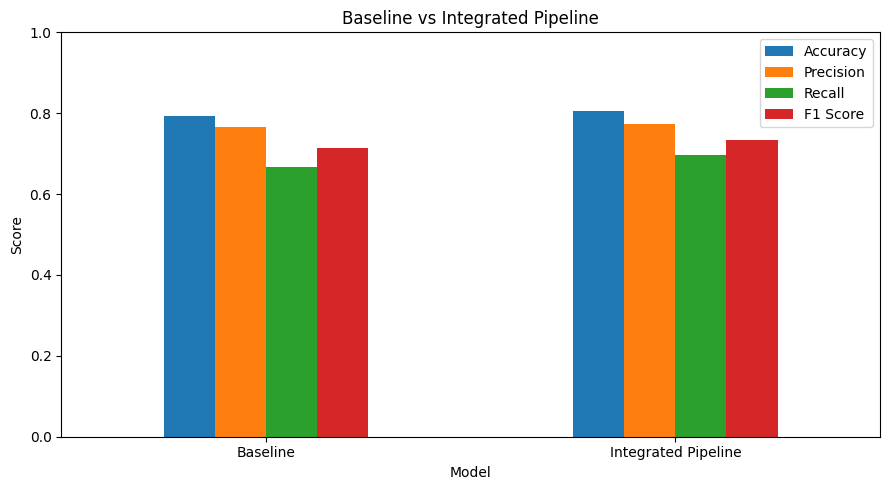

In [28]:
comparison.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Integrated Pipeline")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Pipeline Serialization

The trained pipeline is serialized using Joblib.

Saving the complete pipeline instead of only the model ensures that the same feature engineering and preprocessing steps are automatically applied when the model is loaded for inference.

In [29]:
os.makedirs("models", exist_ok=True)

model_path = "models/titanic_pipeline.joblib"

joblib.dump(pipeline, model_path)

print(f"Pipeline saved successfully to: {model_path}")

Pipeline saved successfully to: models/titanic_pipeline.joblib


In [30]:
loaded_pipeline = joblib.load(model_path)

print("Pipeline loaded successfully.")
print(type(loaded_pipeline))

Pipeline loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [31]:
loaded_predictions = loaded_pipeline.predict(X_test)

loaded_accuracy = accuracy_score(y_test, loaded_predictions)

print("Loaded Pipeline Verification")
print("----------------------------------------")
print(f"Accuracy: {loaded_accuracy:.4f}")

print("\nPredictions identical to original pipeline:",
      np.array_equal(y_pred, loaded_predictions))

Loaded Pipeline Verification
----------------------------------------
Accuracy: 0.8045

Predictions identical to original pipeline: True


## 9. Pipeline Leakage and Reproducibility Check

The final workflow keeps feature engineering and preprocessing inside the Scikit-Learn pipeline. The pipeline is fitted only on the training data and then applied to unseen test data.

This design reduces the risk of preprocessing inconsistencies and helps ensure that the same transformations are used during training and inference.

The serialized pipeline can be loaded later and used directly for prediction without manually repeating preprocessing steps.

In [32]:
print("TASK 10 FINAL SUMMARY")
print("=" * 50)

print(f"Baseline Accuracy:           {baseline_accuracy:.4f}")
print(f"Integrated Pipeline Accuracy:{pipeline_accuracy:.4f}")
print(f"Accuracy Difference:         {pipeline_accuracy - baseline_accuracy:+.4f}")

print("\nPipeline saved at:")
print(model_path)

print("\nSerialization verified:")
print(np.array_equal(y_pred, loaded_predictions))

TASK 10 FINAL SUMMARY
Baseline Accuracy:           0.7933
Integrated Pipeline Accuracy:0.8045
Accuracy Difference:         +0.0112

Pipeline saved at:
models/titanic_pipeline.joblib

Serialization verified:
True


## 5. Custom Feature Engineering

A custom Scikit-Learn transformer is used to create a new `FamilySize` feature from the existing `SibSp` and `Parch` variables.

This feature represents the total number of family members travelling with the passenger, including the passenger themselves.

Integrating this transformation into the pipeline ensures that the feature is generated consistently during both training and inference.

In [33]:
class FamilySizeTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        return X

In [34]:
feature_engineer = FamilySizeTransformer()

X_train_transformed = feature_engineer.fit_transform(X_train)
X_test_transformed = feature_engineer.transform(X_test)

print("Original features:", X_train.shape[1])
print("Features after transformation:", X_train_transformed.shape[1])

display(
    X_train_transformed[
        ["SibSp", "Parch", "FamilySize"]
    ].head()
)

Original features: 7
Features after transformation: 8


,SibSp,Parch,FamilySize
692,0,0,1
481,0,0,1
527,0,0,1
855,0,1,2
801,1,1,3


## 6. Feature Union

FeatureUnion is used to combine outputs from multiple feature-processing branches into a single feature representation.

In this task, it demonstrates how different transformation paths can be combined before model training while keeping the workflow modular.

In [35]:
numeric_branch = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_branch = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

## 6. ColumnTransformer for Preprocessing

Different types of features require different preprocessing strategies. Numerical features are imputed using the median and scaled, while categorical features are imputed using the most frequent value and one-hot encoded.

A ColumnTransformer combines these transformations into a single preprocessing component. This keeps the preprocessing organized and ensures that the same transformations are applied consistently to the appropriate columns.

In [36]:
numeric_features_updated = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

categorical_features_updated = [
    "Sex",
    "Embarked"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_updated),
        ("cat", categorical_pipeline, categorical_features_updated)
    ]
)

print("ColumnTransformer created successfully.")

ColumnTransformer created successfully.


In [37]:
X_train_transformed = feature_engineer.fit_transform(X_train)

X_train_processed = preprocessor.fit_transform(X_train_transformed)

print("Preprocessing completed successfully.")
print("Processed training data shape:", X_train_processed.shape)

Preprocessing completed successfully.
Processed training data shape: (712, 11)


## 7. Complete Machine Learning Pipeline

The custom feature engineering and preprocessing steps are now combined with a Random Forest classifier into one Scikit-Learn Pipeline.

The pipeline ensures that feature creation, missing-value handling, scaling, categorical encoding, and model training are executed as one reproducible workflow.

This design helps prevent inconsistencies between training and inference because the same sequence of transformations is automatically applied whenever the pipeline is used.

In [38]:
final_pipeline = Pipeline(steps=[
    ("feature_engineering", FamilySizeTransformer()),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

print("Complete pipeline created successfully.")

Complete pipeline created successfully.


In [39]:
final_pipeline.fit(X_train, y_train)

print("Complete pipeline training completed successfully.")

Complete pipeline training completed successfully.


In [40]:
pipeline_pred = final_pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(pipeline_pred))

Predictions generated successfully.
Number of predictions: 179


In [41]:
pipeline_accuracy = accuracy_score(y_test, pipeline_pred)
pipeline_precision = precision_score(y_test, pipeline_pred, zero_division=0)
pipeline_recall = recall_score(y_test, pipeline_pred, zero_division=0)
pipeline_f1 = f1_score(y_test, pipeline_pred, zero_division=0)

print("Integrated Pipeline Results")
print("----------------------------------------")
print(f"Accuracy: {pipeline_accuracy:.4f}")
print(f"Precision: {pipeline_precision:.4f}")
print(f"Recall: {pipeline_recall:.4f}")
print(f"F1 Score: {pipeline_f1:.4f}")

Integrated Pipeline Results
----------------------------------------
Accuracy: 0.8045
Precision: 0.7742
Recall: 0.6957
F1 Score: 0.7328


In [42]:
print("Classification Report")
print("----------------------------------------")

print(classification_report(
    y_test,
    pipeline_pred,
    target_names=["Did Not Survive", "Survived"],
    zero_division=0
))

Classification Report
----------------------------------------
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



## 8. Confusion Matrix

A confusion matrix is used to examine the types of correct and incorrect predictions made by the pipeline.

It shows the number of true negatives, false positives, false negatives, and true positives, providing more detail than accuracy alone.

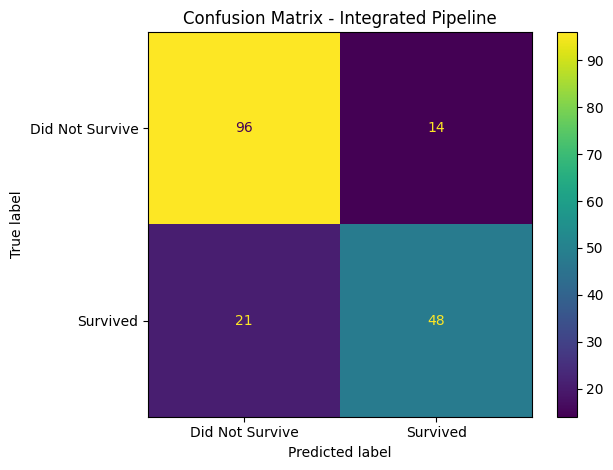

In [43]:
cm = confusion_matrix(y_test, pipeline_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

disp.plot()
plt.title("Confusion Matrix - Integrated Pipeline")
plt.tight_layout()
plt.show()

## 9. Baseline Model

A Logistic Regression model is used as a simple baseline. The baseline provides a reference point for evaluating the performance of the more complete Random Forest pipeline.

The baseline uses the same core preprocessing strategy so that the comparison focuses primarily on the modeling approach rather than inconsistent data preparation.

In [44]:
baseline_pipeline = Pipeline(steps=[
    ("feature_engineering", FamilySizeTransformer()),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline Logistic Regression Results")
print("----------------------------------------")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1 Score: {baseline_f1:.4f}")

Baseline Logistic Regression Results
----------------------------------------
Accuracy: 0.8045
Precision: 0.7931
Recall: 0.6667
F1 Score: 0.7244


## 10. Model Comparison

The integrated Random Forest pipeline is compared with the Logistic Regression baseline using accuracy, precision, recall, and F1 score.

The comparison helps determine whether the more complex model provides a meaningful performance advantage over a simpler baseline.

In [45]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "Random Forest Pipeline"
    ],
    "Accuracy": [
        baseline_accuracy,
        pipeline_accuracy
    ],
    "Precision": [
        baseline_precision,
        pipeline_precision
    ],
    "Recall": [
        baseline_recall,
        pipeline_recall
    ],
    "F1 Score": [
        baseline_f1,
        pipeline_f1
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression Baseline,0.8045,0.7931,0.6667,0.7244
1,Random Forest Pipeline,0.8045,0.7742,0.6957,0.7328


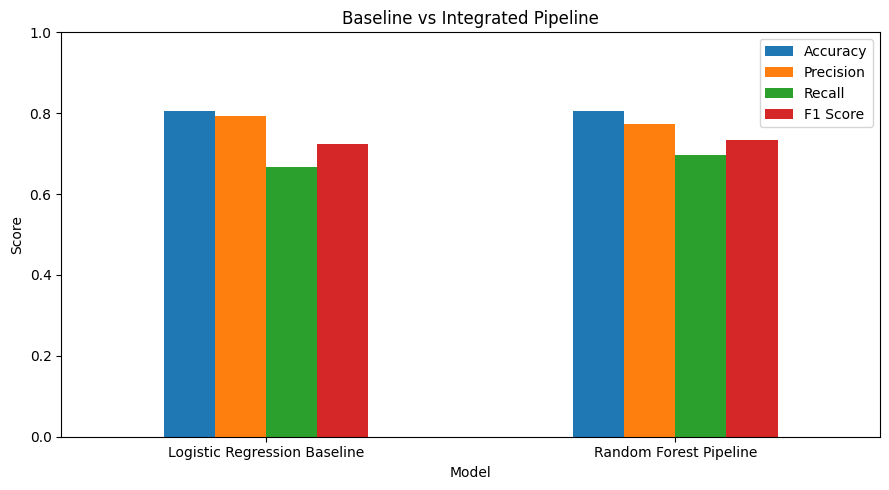

In [46]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Integrated Pipeline")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

## 11. FeatureUnion

FeatureUnion combines the outputs of multiple transformer branches into a single feature representation.

For demonstration, two preprocessing branches are created and combined. This illustrates how parallel transformation workflows can be organized within Scikit-Learn.

In [47]:
from sklearn.pipeline import FeatureUnion

feature_union = FeatureUnion([
    ("scaled_numeric", numeric_pipeline),
    ("categorical", categorical_pipeline)
])

print("FeatureUnion created successfully.")

FeatureUnion created successfully.


## 12. Pipeline Serialization

The complete trained pipeline is serialized using Joblib.

Serializing the complete pipeline allows the feature engineering, preprocessing, and model to be saved together. When the pipeline is loaded later, the same transformations can be automatically applied before generating predictions.

In [48]:
os.makedirs("models", exist_ok=True)

model_path = "models/titanic_pipeline.joblib"

joblib.dump(final_pipeline, model_path)

print("Pipeline saved successfully.")
print("Saved file:", model_path)

Pipeline saved successfully.
Saved file: models/titanic_pipeline.joblib


In [49]:
loaded_pipeline = joblib.load(model_path)

loaded_pred = loaded_pipeline.predict(X_test)

loaded_accuracy = accuracy_score(y_test, loaded_pred)

print("Loaded Pipeline Verification")
print("----------------------------------------")
print(f"Loaded Pipeline Accuracy: {loaded_accuracy:.4f}")

print(
    "Predictions identical:",
    np.array_equal(pipeline_pred, loaded_pred)
)

Loaded Pipeline Verification
----------------------------------------
Loaded Pipeline Accuracy: 0.8045
Predictions identical: True


## 13. Important Findings

- The integrated Random Forest pipeline achieved 80.45% test accuracy.
- The Logistic Regression baseline also achieved 80.45% accuracy.
- Although accuracy remained the same, the Random Forest pipeline achieved slightly higher recall (69.57%) and F1 score (73.28%) than the baseline.
- The pipeline successfully combined custom feature engineering, numerical preprocessing, categorical encoding, and model training into one workflow.
- Joblib serialization was successfully verified, with the loaded pipeline producing the same predictions as the original pipeline.

## 14. Business Insights

The main business value of the solution is consistency and reproducibility rather than a large increase in predictive accuracy.

The complete pipeline reduces the risk of training and inference preprocessing differences. A single reusable pipeline also makes deployment and maintenance easier because feature engineering, preprocessing, and prediction are handled together.

The results show that a more complex pipeline does not necessarily guarantee higher accuracy, but it provides a more reliable and maintainable machine learning workflow.

## 15. Limitations

- The Titanic dataset is relatively small and historical.
- Only selected passenger features were used in the final pipeline.
- The integrated pipeline did not improve test accuracy over the Logistic Regression baseline.
- Model performance may change with different feature engineering strategies, algorithms, or train-test splits.
- Further model tuning and additional feature engineering could be explored in future work.

## 16. Conclusion

This task successfully implemented a reproducible Scikit-Learn machine learning pipeline for Titanic survival prediction.

The final workflow integrates custom feature engineering, ColumnTransformer-based preprocessing, Random Forest classification, evaluation, and Joblib serialization into a single pipeline. The integrated pipeline achieved 80.45% test accuracy, while the saved and reloaded pipeline produced identical predictions.

Although the pipeline did not increase accuracy compared with the baseline, it successfully addressed the main engineering problem of maintaining a consistent and reusable preprocessing and prediction workflow.

## 17. Learning Outcomes

Through this task, I learned how to:

- Build Scikit-Learn Pipelines.
- Use ColumnTransformer for mixed data types.
- Create custom transformers.
- Combine feature-processing workflows.
- Prevent preprocessing inconsistencies and potential data leakage.
- Evaluate machine learning pipelines against a baseline.
- Serialize and reload complete pipelines using Joblib.
- Design reproducible and modular ML workflows.